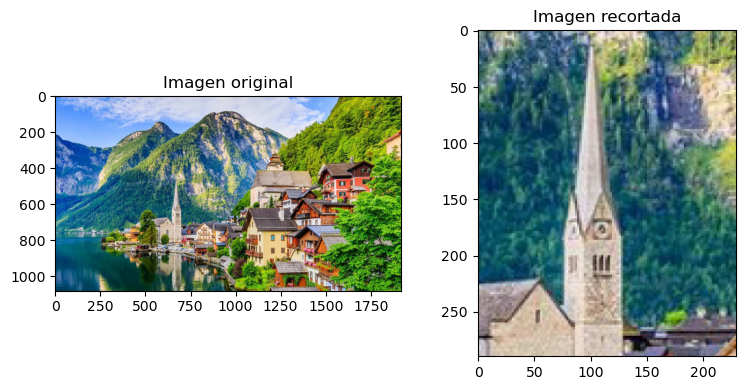

In [27]:
import cv2
import matplotlib.pyplot as plt


img = cv2.imread('mod 4.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


y_ini, y_fin = 450, 740
x_ini, x_fin = 570, 800

crop = img_rgb[y_ini:y_fin, x_ini:x_fin]

cv2.imwrite('mod4_recorte.jpg', cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('on')

plt.subplot(1,2,2)
plt.imshow(crop)
plt.title('Imagen recortada')
plt.axis('on')

plt.tight_layout()
plt.show()


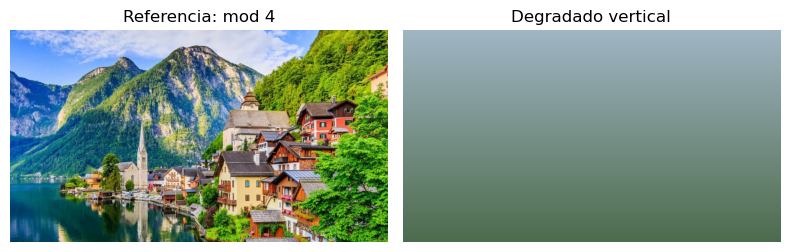

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Img ref
ref = cv2.imread('mod 4.jpeg')
ref_rgb = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)

alto, ancho, _ = ref_rgb.shape

c_sup = ref_rgb[0, :, :].mean(axis=0).astype(np.float32)
c_inf = ref_rgb[-1, :, :].mean(axis=0).astype(np.float32)

grad = np.zeros((alto, ancho, 3), dtype=np.float32)

for i in range(alto):
    t = i / (alto - 1)        
    color = (1 - t) * c_sup + t * c_inf
    grad[i, :, :] = color      

grad_uint8 = np.clip(grad, 0, 255).astype(np.uint8)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(ref_rgb)
plt.title('Referencia: mod 4')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(grad_uint8)
plt.title('Degradado vertical')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.imsave('degradado_vertical_mod4.png', grad_uint8)



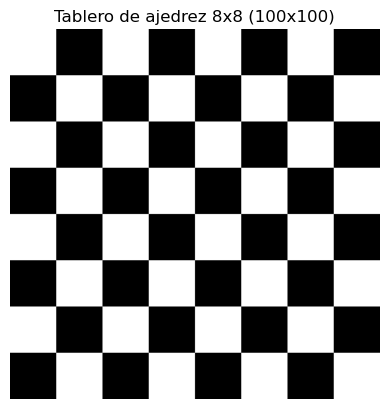

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_filas = 8
n_cols = 8
lado = 100

alto = n_filas * lado
ancho = n_cols * lado

tablero = np.zeros((alto, ancho), dtype=np.uint8)

for i in range(n_filas):
    for j in range(n_cols):
        if (i + j) % 2 == 0:
            y_ini = i * lado 
            y_fin = (i + 1) * lado
            x_ini = j * lado
            x_fin = (j + 1) * lado
            tablero[y_ini:y_fin, x_ini:x_fin] = 255

plt.imshow(tablero, cmap='gray')
plt.title('Tablero de ajedrez 8x8 (100x100)')
plt.axis('off')
plt.show()

plt.imsave('tablero_ajedrez.png', tablero, cmap='gray')


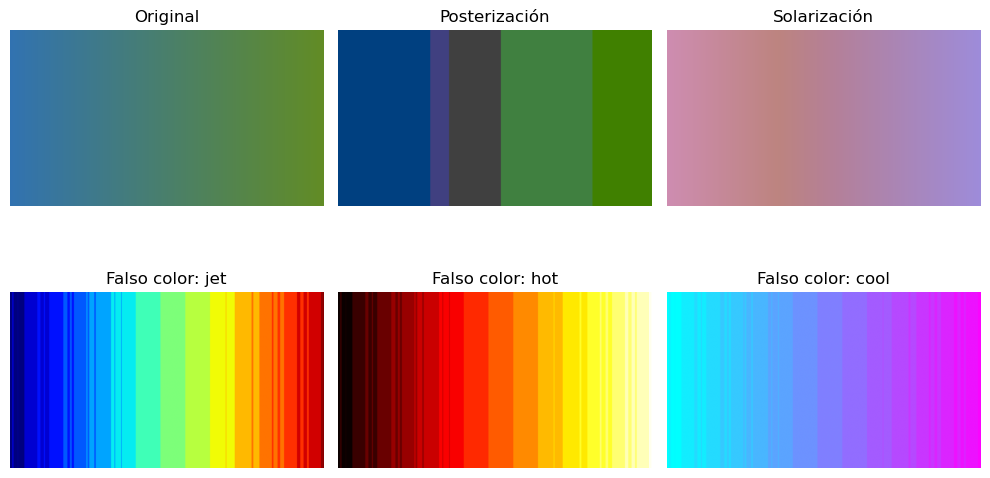

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

grad = cv2.imread('degradado_mod4.png')
grad = cv2.cvtColor(grad, cv2.COLOR_BGR2RGB)

# Posterización
niveles = 4
factor = 256 // niveles
poster = (grad // factor) * factor

# Solarización
umbral = 128
solar = grad.copy()
solar[solar < umbral] = 255 - solar[solar < umbral]

# Falsos colores
grad_gray = cv2.cvtColor(grad, cv2.COLOR_RGB2GRAY)
colormaps = ['jet', 'hot', 'cool', 'spring', 'summer', 'winter']

plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(grad)
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(poster)
plt.title('Posterización')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(solar)
plt.title('Solarización')
plt.axis('off')

for k, cmap in enumerate(colormaps[:3]):
    plt.subplot(2,3,4+k)
    plt.imshow(grad_gray, cmap=cmap)
    plt.title(f'Falso color: {cmap}')
    plt.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('grad_poster.png', cv2.cvtColor(poster, cv2.COLOR_RGB2BGR))
cv2.imwrite('grad_solar.png', cv2.cvtColor(solar, cv2.COLOR_RGB2BGR))

for cmap in colormaps:
    plt.imsave(f'grad_falso_{cmap}.png', grad_gray, cmap=cmap)


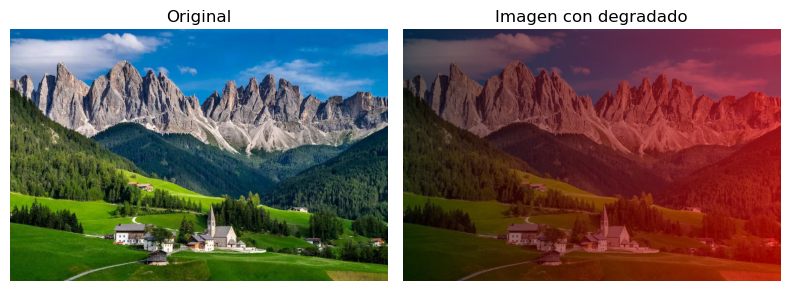

True

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

alto, ancho, _ = img_rgb.shape

# Degradado horizontal en rojo
x = np.linspace(0, 1, ancho)
grad = np.tile(x, (alto, 1))

grad3 = np.zeros((alto, ancho, 3), dtype=np.float32)
grad3[:, :, 0] = grad

img_float = img_rgb.astype(np.float32) / 255.0
alpha = 0.6

img_grad = img_float * (1 - alpha) + grad3 * alpha
img_grad_uint8 = (np.clip(img_grad, 0, 1) * 255).astype(np.uint8)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_grad_uint8)
plt.title('Imagen con degradado')
plt.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('imagen1_degradado.png', cv2.cvtColor(img_grad_uint8, cv2.COLOR_RGB2BGR))


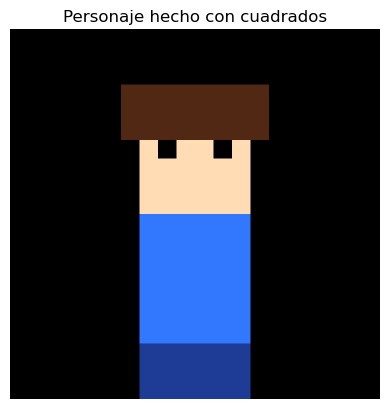

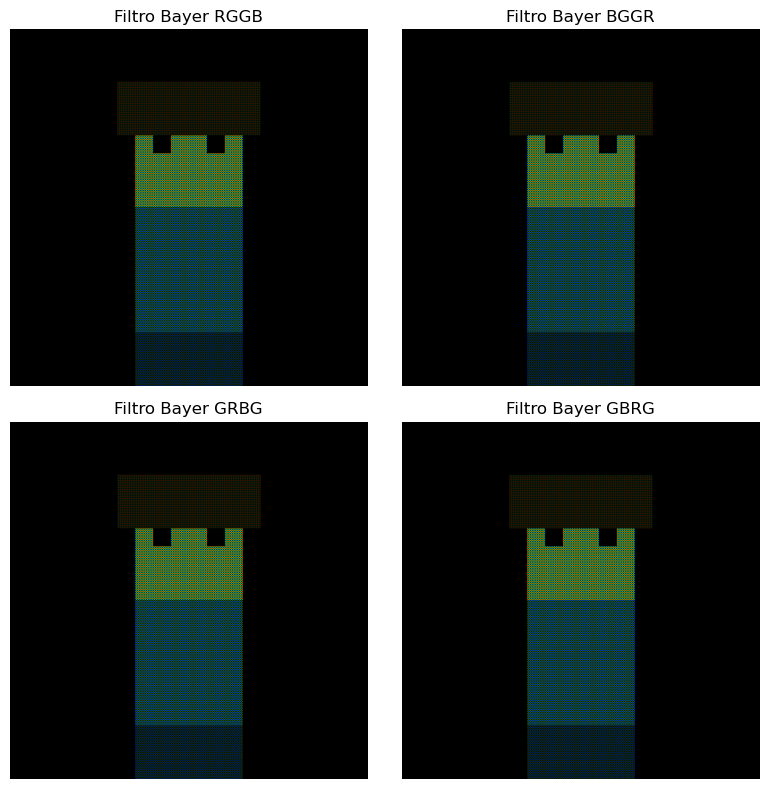

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


alto = 400
ancho = 400
lado = 20  

img = np.zeros((alto, ancho, 3), dtype=np.uint8)


filas = alto // lado
cols = ancho // lado


def pintar_celda(fi, co, color):
    y_ini = fi * lado
    y_fin = (fi + 1) * lado
    x_ini = co * lado
    x_fin = (co + 1) * lado
    img[y_ini:y_fin, x_ini:x_fin, :] = color

# Definimos colores (RGB)
piel   = (255, 220, 180)
cabello = (80, 40, 20)
ropa1  = (50, 120, 255)
ropa2  = (30, 60, 150)
fondo  = (0, 0, 0)


# Cabeza (un cuadrado grande)
for fi in range(4, 10):
    for co in range(7, 13):
        pintar_celda(fi, co, piel)

# Cabello
for fi in range(3, 6):
    for co in range(6, 14):
        pintar_celda(fi, co, cabello)

# Ojos
pintar_celda(6, 8, (0, 0, 0))
pintar_celda(6, 11, (0, 0, 0))

# Cuerpo / camisa
for fi in range(10, 17):
    for co in range(7, 13):
        pintar_celda(fi, co, ropa1)

# Pantalón
for fi in range(17, 20):
    for co in range(7, 13):
        pintar_celda(fi, co, ropa2)

# Piernas
for fi in range(20, 23):
    for co in range(8, 10):
        pintar_celda(fi, co, ropa2)
    for co in range(10, 12):
        pintar_celda(fi, co, ropa2)

plt.imshow(img)
plt.title('Personaje hecho con cuadrados')
plt.axis('off')
plt.show()

cv2.imwrite('personaje_cuadrados.png', cv2.cvtColor(img, cv2.COLOR_RGB2BGR))



def aplicar_bayer(imagen, patron='RGGB'):
    h, w, _ = imagen.shape
    mosaico = np.zeros_like(imagen)

    for y in range(h):
        for x in range(w):
            if patron == 'RGGB':
                if y % 2 == 0 and x % 2 == 0:
                    mosaico[y,x,0] = imagen[y,x,0]
                elif y % 2 == 0 and x % 2 == 1:
                    mosaico[y,x,1] = imagen[y,x,1]
                elif y % 2 == 1 and x % 2 == 0:
                    mosaico[y,x,1] = imagen[y,x,1]
                else:
                    mosaico[y,x,2] = imagen[y,x,2]
            elif patron == 'BGGR':
                if y % 2 == 0 and x % 2 == 0:
                    mosaico[y,x,2] = imagen[y,x,2]
                elif y % 2 == 0 and x % 2 == 1:
                    mosaico[y,x,1] = imagen[y,x,1]
                elif y % 2 == 1 and x % 2 == 0:
                    mosaico[y,x,1] = imagen[y,x,1]
                else:
                    mosaico[y,x,0] = imagen[y,x,0]
            elif patron == 'GRBG':
                if y % 2 == 0 and x % 2 == 0:
                    mosaico[y,x,1] = imagen[y,x,1]
                elif y % 2 == 0 and x % 2 == 1:
                    mosaico[y,x,0] = imagen[y,x,0]
                elif y % 2 == 1 and x % 2 == 0:
                    mosaico[y,x,2] = imagen[y,x,2]
                else:
                    mosaico[y,x,1] = imagen[y,x,1]
            elif patron == 'GBRG':
                if y % 2 == 0 and x % 2 == 0:
                    mosaico[y,x,1] = imagen[y,x,1]
                elif y % 2 == 0 and x % 2 == 1:
                    mosaico[y,x,2] = imagen[y,x,2]
                elif y % 2 == 1 and x % 2 == 0:
                    mosaico[y,x,0] = imagen[y,x,0]
                else:
                    mosaico[y,x,1] = imagen[y,x,1]
    return mosaico

patrones = ['RGGB', 'BGGR', 'GRBG', 'GBRG']
resultados = {}

plt.figure(figsize=(8,8))
for k, p in enumerate(patrones):
    mos = aplicar_bayer(img, p)
    resultados[p] = mos
    plt.subplot(2,2,k+1)
    plt.imshow(mos)
    plt.title(f'Filtro Bayer {p}')
    plt.axis('off')
plt.tight_layout()
plt.show()

for p, mos in resultados.items():
    cv2.imwrite(f'personaje_bayer_{p}.png', cv2.cvtColor(mos, cv2.COLOR_RGB2BGR))
